In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.chdir('/media/sf_OneDrive_-_Fraunhofer/Projekte/CERERE/rl-test/visualizations')

In [18]:
!pip install PyQt5

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 7.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 7.1 MB/s eta 0:00:0000:0100:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [47]:
def process_data(filepath):
    # Read data to pandas df
    df = pd.read_csv(filepath)
    # Remove nan values
    return df


def generate_plots(filepath, x_value, y_values, export_to_file=False):
    df = process_data(filepath)

    # df.plot(x="time/time_elapsed", y="train/value_loss", kind="line")
    # plt.plot(df["time/time_elapsed"], df["train/value_loss"])
    
    plot_data_columns = {}
    
    plot_data_columns[x_value.split('/')[-1]] = df[x_value]
    for y in y_values:
        plot_data_columns[y.split('/')[-1]] = df[y]
   
    plot_data = pd.DataFrame(plot_data_columns)

    # plot_data = pd.DataFrame({'steps': df['time/total_timesteps'], 'value_loss': df['train/value_loss'],
    #                           'ep_rew_mean': df['rollout/ep_rew_mean']})

    plot_data.plot(x='total_timesteps', style='.-')
    
    if export_to_file:
        filename = x_value.split('/')[-1] + "," + ",".join(y_val.split('/')[-1] for y_val in y_values)
        plt.savefig(filename+'.png', bbox_inches='tight')
        
    plt.show()

In [39]:
filepath = "../tb_log/progress.csv"
print("Available Data Columns:")
col_str = ", ".join(col for col in process_data(filepath).columns)
print(col_str)

Available Data Columns:
time/time_elapsed, time/fps, rollout/ep_rew_mean, time/iterations, time/total_timesteps, rollout/ep_len_mean, train/clip_range, train/learning_rate, train/entropy_loss, train/explained_variance, train/approx_kl, train/clip_fraction, train/value_loss, train/policy_gradient_loss, train/loss, train/n_updates


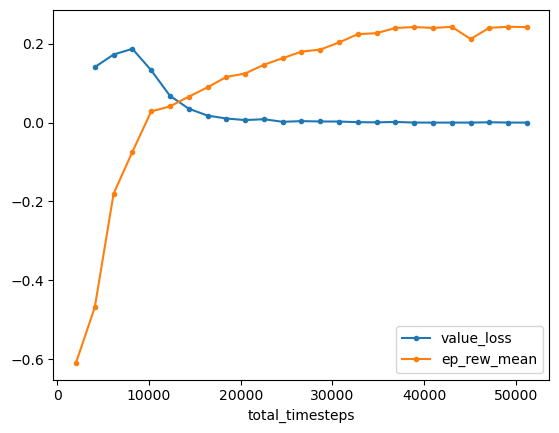

In [48]:
# Mean reward and value loss over step time
generate_plots(filepath, x_value='time/total_timesteps', y_values=['train/value_loss', 'rollout/ep_rew_mean'],
               export_to_file=True)

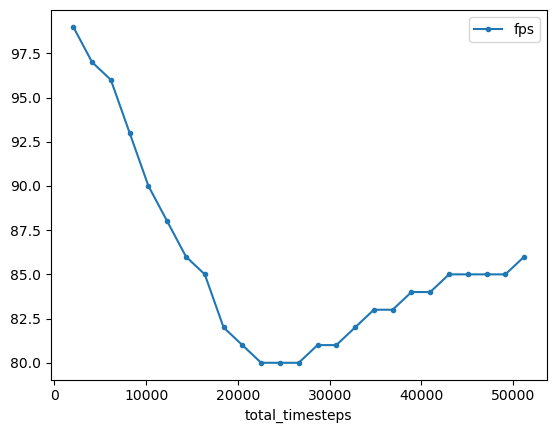

In [35]:
generate_plots(filepath, x_value='time/total_timesteps', y_values=['time/fps'])

In [43]:
os.getcwd()

'/media/sf_OneDrive_-_Fraunhofer/Projekte/CERERE/rl-test/visualizations'